# Data Preprocessing & Exploration

## Initialization

In [34]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display

## Loading Data

In [35]:
df = pd.read_csv('insurance_us.csv')

I renamed the columns to make the code more consistent with its style.

In [36]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [37]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
1504,0,21.0,44800.0,2,0
538,0,23.0,43400.0,0,0
3551,0,39.0,51500.0,0,0
4945,1,21.0,45800.0,0,0
4817,0,18.0,50000.0,1,0
3966,1,23.0,40200.0,2,0
2826,0,32.0,48700.0,2,0
1235,0,47.0,42500.0,2,1
2905,0,28.0,23700.0,2,0
3253,1,31.0,30800.0,0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [39]:
# fixing the age type from float to int
df['age'] = df['age'].astype(int)

In [40]:
# verifying the type conversion
df.dtypes

gender                  int64
age                     int64
income                float64
family_members          int64
insurance_benefits      int64
dtype: object

In [41]:
# checking descriptive statistics of the data
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


After converting the age column type, I verified that the data contains no missing values or inconsistencies.
The descriptive statistics show that all variables are within realistic ranges and present no obvious outliers.
Therefore, the data is suitable for applying machine learning models in the next steps.

## EDA

I quickly checked whether there are any distinct customer groups by looking at the pair plot.

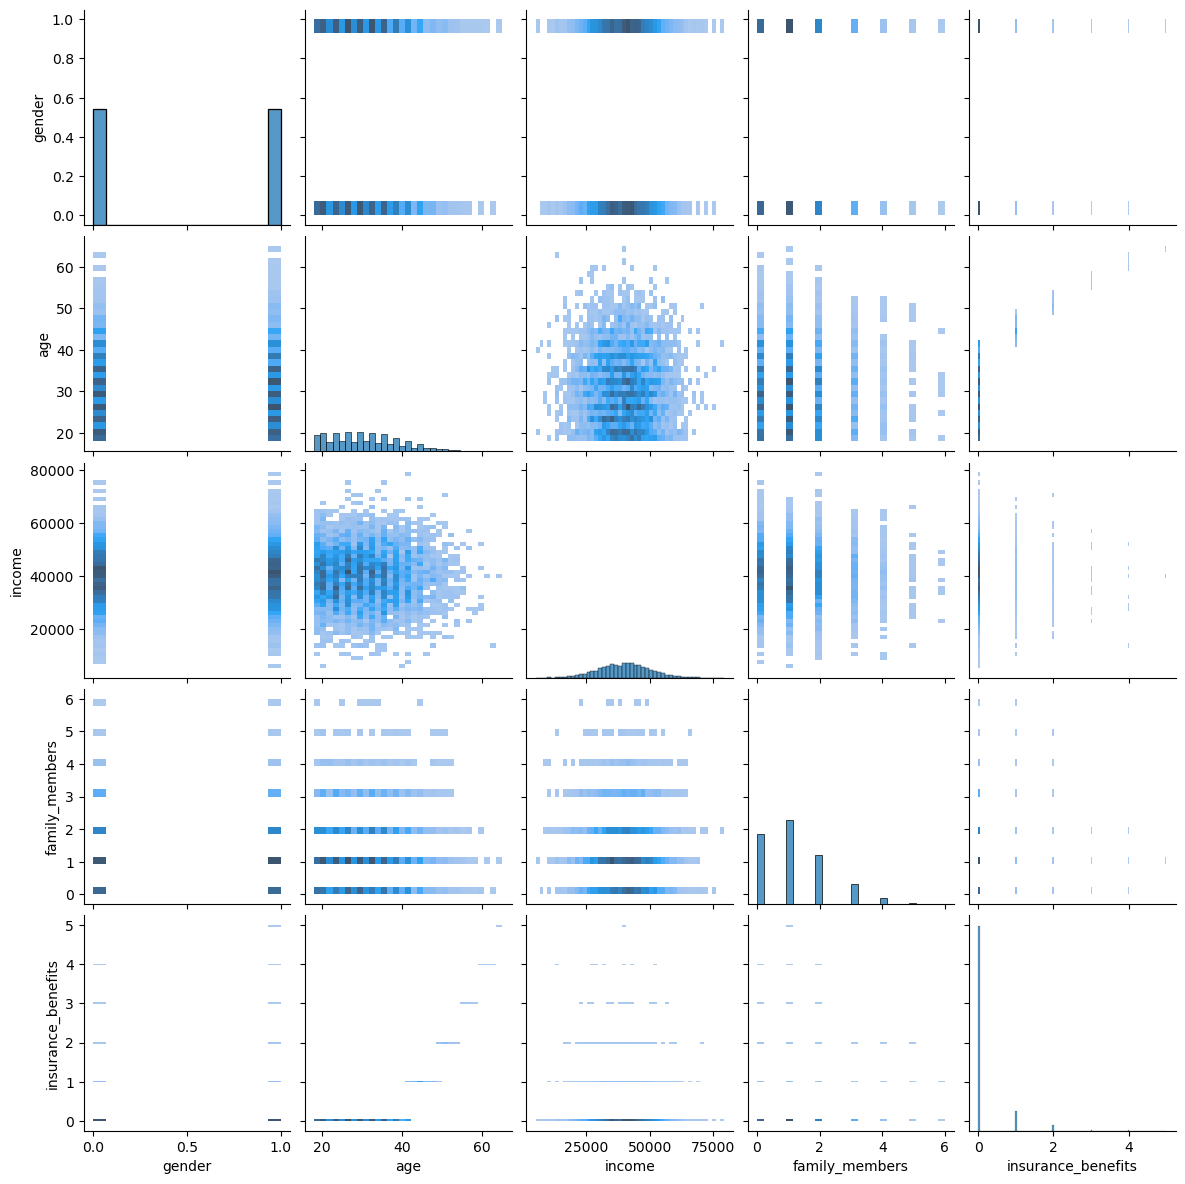

In [42]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

- It's somewhat difficult to identify obvious clusters, as it's hard to combine
- multiple variables simultaneously to analyze multivariate distributions.
- This is where Linear Algebra and Machine Learning can be quite useful.

# Part 1 — Finding Similar Customers

In this first part, I build a nearest neighbor search to identify customers with similar profiles. Finding similarities between customers is a powerful 
way to support marketing decisions, and I wanted to understand how different 
distance metrics and scaling strategies affect the quality of those comparisons. 
I test four combinations of Euclidean and Manhattan distances, with and without 
MaxAbsScaler, to see how each one influences the results.

In [43]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [44]:
def get_knn(df, n, k, metric):
    """
    Returns the k nearest neighbors for a given object.
    :param df: pandas DataFrame used to find similar objects within
    :param n: index of the object to search neighbors for
    :param k: number of nearest neighbors to return
    :param metric: name of the distance metric
    """
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors(df.iloc[[n]][feature_names], k, return_distance=True)

    df_res = pd.concat([
        df.iloc[nbrs_indices[0]],
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
    ], axis=1)

    return df_res

Scaling the data

In [45]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled[feature_names] = df_scaled[feature_names].astype(float)
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [46]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
2297,0.0,0.307692,0.512658,0.833333,0
33,0.0,0.476923,0.355696,0.000000,0
3143,0.0,0.661538,0.616456,0.000000,1
3478,0.0,0.738462,0.325316,0.166667,1
3238,0.0,0.461538,0.575949,0.333333,0


- Getting similar records for a given entry across each combination

In [47]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors

feature_names = ['gender', 'age', 'income', 'family_members']

def get_knn(df, n, k, metric):
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names])
    distances, indices = nbrs.kneighbors(
        df.iloc[[n]][feature_names],
        k,
        return_distance=True
    )
    return pd.concat(
        [
            df.iloc[indices[0]],
            pd.DataFrame(distances.T, index=indices[0], columns=['distance'])
        ],
        axis=1
    )

get_knn(df, n=0, k=5, metric='euclidean')
get_knn(df, n=0, k=5, metric='manhattan')

,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.0
2022,1,41,49600.0,0,0,1.0
1225,0,42,49600.0,0,1,3.0
4031,1,44,49600.0,2,1,4.0
815,1,37,49600.0,2,0,5.0


In [48]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler().fit(df[feature_names])
df_scaled = df.copy()
df_scaled[feature_names] = scaler.transform(df[feature_names])

get_knn(df_scaled, n=0, k=5, metric='euclidean')
get_knn(df_scaled, n=0, k=5, metric='manhattan')

,gender,age,income,family_members,insurance_benefits,distance
0,1.0,0.630769,0.627848,0.166667,0,0.000000
2689,1.0,0.630769,0.634177,0.166667,0,0.006329
133,1.0,0.615385,0.636709,0.166667,0,0.024245
4869,1.0,0.646154,0.637975,0.166667,1,0.025511
2103,1.0,0.630769,0.596203,0.166667,0,0.031646


# Part 2 — Insurance Benefit Prediction

Here I approach the problem from a classification angle. I want to know whether 
it is possible to predict if a customer will receive any insurance payment at all. 
I create a binary target variable, train a KNN classifier, and measure its 
performance using the F1 score across different values of k. To put the results 
in perspective, I also build a dummy random model as a baseline and compare both.

In [49]:
# calculating the target variable
df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [50]:
# checking class imbalance
df['insurance_benefits_received'].value_counts()
df['insurance_benefits_received'].value_counts(normalize=True)

insurance_benefits_received
0    0.8872
1    0.1128
Name: proportion, dtype: float64

In [51]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)

In [52]:
# generating output from a random model
def rnd_model_predict(P, size, seed=42):
    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [53]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:
    print(f'Probability: {P:.2f}')
    y_pred_rnd = rnd_model_predict(
        P=P,
        size=len(df['insurance_benefits_received'])
    )

    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)

    print()

Probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

Probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

Probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

Probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



# Part 3 — Linear Regression

Rather than predicting whether a customer receives a payment, I go a step further 
and estimate how many payments they are likely to receive. Instead of relying on 
a ready-made implementation, I build the linear regression model entirely from 
scratch using NumPy and the closed-form analytical solution from linear algebra. 
I then evaluate it with RMSE and R² on both original and scaled data to confirm 
the model behaves as expected.

In [54]:
class MyLinearRegression:
    
    def __init__(self):
        self.weights = None
    
    def fit(self, X, y):
        # adding bias term
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y

    def predict(self, X):
        # adding bias term
        X2 = np.append(np.ones((X.shape[0], 1)), X, axis=1)
        y_pred = X2 @ self.weights
        
        return y_pred

In [55]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def eval_regressor(y_true, y_pred):
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    r2 = r2_score(y_true, y_pred)
    print(f'R2: {r2:.2f}')

In [56]:
# splitting X and y
X = df[feature_names].to_numpy()
y = df['insurance_benefits'].to_numpy()

# 70:30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# training the model
model = MyLinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# calculating RMSE
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f'RMSE (original data): {rmse:.2f}')

RMSE (original data): 0.36


In [57]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()
lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.43


# Part 4 — Data Obfuscation

In this final part, I tackle one of the most important real-world concerns in 
data science: privacy. I develop a data obfuscation method by multiplying the 
feature matrix by a randomly generated invertible matrix, making the original 
data unreadable without knowledge of that matrix. Before testing it, I prove 
analytically that this transformation leaves the linear regression predictions 
completely unchanged, then confirm it experimentally by comparing RMSE and R² 
before and after obfuscation.

In [58]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [59]:
X = df_pn.to_numpy()

- Generating a random matrix $P$

In [60]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

- Checking if matrix $P$ is invertible

In [61]:
det_P = np.linalg.det(P)
print(f'Determinant of P: {det_P}')

Determinant of P: 0.24339135998015468


In [62]:
# obfuscating the data
X_obfuscated = X @ P

# inverting matrix P
P_inv = np.linalg.inv(P)

# recovering the original data
X_recovered = X_obfuscated @ P_inv

# printing all three cases for a few customers
for i in range(5):
    print(f'Customer {i}')
    print('Original   :', X[i])
    print('Transformed:', X_obfuscated[i])
    print('Recovered  :', X_recovered[i])
    print()

Customer 0
Original   : [1.00e+00 4.10e+01 4.96e+04 1.00e+00]
Transformed: [ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
Recovered  : [1.00e+00 4.10e+01 4.96e+04 1.00e+00]

Customer 1
Original   : [0.0e+00 4.6e+01 3.8e+04 1.0e+00]
Transformed: [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
Recovered  : [6.66555413e-13 4.60000000e+01 3.80000000e+04 1.00000000e+00]

Customer 2
Original   : [    0.    29. 21000.     0.]
Transformed: [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
Recovered  : [-1.43424173e-12  2.90000000e+01  2.10000000e+04  1.41940791e-12]

Customer 3
Original   : [0.00e+00 2.10e+01 4.17e+04 2.00e+00]
Transformed: [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
Recovered  : [-2.69875101e-12  2.10000000e+01  4.17000000e+04  2.00000000e+00]

Customer 4
Original   : [1.00e+00 2.80e+01 2.61e+04 0.00e+00]
Transformed: [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]
Recovered  : [1.00000000e+00 2.80000000

## Proof That Data Obfuscation Works with Linear Regression

In [63]:
import numpy as np

np.random.seed(42)
n_features = X.shape[1]

# generating an invertible matrix P
while True:
    P = np.random.randn(n_features, n_features)
    if np.linalg.det(P) != 0:
        break

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# training on original data
model_original = LinearRegression()
model_original.fit(X, y)
y_pred_original = model_original.predict(X)

# training on obfuscated data
X_obfuscated = X @ P
model_obfuscated = LinearRegression()
model_obfuscated.fit(X_obfuscated, y)
y_pred_obfuscated = model_obfuscated.predict(X_obfuscated)

In [65]:
# evaluating model metrics
rmse_original = np.sqrt(mean_squared_error(y, y_pred_original))
rmse_obfuscated = np.sqrt(mean_squared_error(y, y_pred_obfuscated))
r2_original = r2_score(y, y_pred_original)
r2_obfuscated = r2_score(y, y_pred_obfuscated)

print(f'RMSE (original):    {rmse_original:.10f}')
print(f'RMSE (obfuscated):  {rmse_obfuscated:.10f}')
print(f'R²   (original):    {r2_original:.10f}')
print(f'R²   (obfuscated):  {r2_obfuscated:.10f}')
print()

if np.isclose(rmse_original, rmse_obfuscated) and np.isclose(r2_original, r2_obfuscated):
    print('✅ The RMSE and R² values are identical for both models.')
    print('   Data obfuscation has no impact on linear regression performance.')
else:
    print('❌ The values differ between the original and obfuscated models.')
    print('   Further investigation is needed.')

RMSE (original):    0.3512077582
RMSE (obfuscated):  0.3512077582
R²   (original):    0.4249455029
R²   (obfuscated):  0.4249455029

✅ The RMSE and R² values are identical for both models.
   Data obfuscation has no impact on linear regression performance.
